# 07 — Grad-CAM e interpretabilidade da CNN 2D

Este notebook apresenta os resultados de Grad-CAM aplicados ao baseline CNN 2D.

A etapa usa os artefatos gerados pelo script:

    python scripts/run_gradcam.py

## Entradas

- `reports/tables/gradcam_cases.csv`
- `reports/figures/gradcam/*.png`

## Objetivo

Investigar qualitativamente se a CNN parece concentrar evidência visual em regiões plausíveis da imagem ou se pode estar usando atalhos visuais, como bordas, fundo preto, ruído, contraste global ou artefatos de JPEG.

Este notebook não treina modelo e não recalcula Grad-CAM. Ele apenas organiza os resultados já gerados.


## 1. Contexto metodológico

A CNN foi treinada para classificar imagens JPEG de CT hepática em duas classes:

- `Healthy = 0`;
- `Hepatic_Steatosis = 1`.

A interpretação deve ser cautelosa porque:

- as imagens são JPEG;
- não há DICOM;
- não há NIfTI;
- não há valores HU confiáveis;
- não há metadados clínicos;
- não há informação de scanner, protocolo ou fase;
- não há segmentação hepática;
- `inferred_group_id` é um agrupamento técnico, não uma identificação clínica validada.

O Grad-CAM não valida clinicamente o modelo. Ele apenas ajuda a inspecionar visualmente onde a CNN concentra ativação para uma predição.


In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display


def find_project_root(start: Path) -> Path:
    """Encontra a raiz do projeto a partir do diretório atual do notebook."""
    start = start.resolve()
    candidates = [start] + list(start.parents)

    for candidate in candidates:
        has_reports = (candidate / "reports").exists()
        has_data = (candidate / "data").exists()
        has_src = (candidate / "src").exists()

        if has_reports and has_data and has_src:
            return candidate

    raise FileNotFoundError(
        "Não foi possível encontrar a raiz do projeto. "
        "Execute o notebook dentro do repositório mestrado_ml_visao_computacional."
    )


PROJECT_ROOT = find_project_root(Path.cwd())

GRADCAM_CASES_PATH = PROJECT_ROOT / "reports" / "tables" / "gradcam_cases.csv"
GRADCAM_FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "gradcam"

print("Diretório atual:")
print(Path.cwd())

print("\nRaiz do projeto:")
print(PROJECT_ROOT)

print("\nEntradas:")
print("gradcam_cases:", GRADCAM_CASES_PATH)
print("figures_dir:", GRADCAM_FIGURES_DIR)

print("\nValidação:")
print("gradcam_cases existe:", GRADCAM_CASES_PATH.exists())
print("figures_dir existe:", GRADCAM_FIGURES_DIR.exists())

missing = [
    path for path in [GRADCAM_CASES_PATH, GRADCAM_FIGURES_DIR]
    if not path.exists()
]

if missing:
    raise FileNotFoundError(
        "Entradas não encontradas:\n" + "\n".join(str(path) for path in missing)
    )


Diretório atual:
C:\GitHub\mestrado_ml_visao_computacional\notebooks

Raiz do projeto:
C:\GitHub\mestrado_ml_visao_computacional

Entradas:
gradcam_cases: C:\GitHub\mestrado_ml_visao_computacional\reports\tables\gradcam_cases.csv
figures_dir: C:\GitHub\mestrado_ml_visao_computacional\reports\figures\gradcam

Validação:
gradcam_cases existe: True
figures_dir existe: True


## 2. Carregamento da tabela Grad-CAM

A tabela `gradcam_cases.csv` contém os slices processados, as probabilidades recalculadas e o caminho da figura Grad-CAM correspondente.


In [2]:
gradcam_cases = pd.read_csv(GRADCAM_CASES_PATH)

print("Dimensão:", gradcam_cases.shape)
print("Colunas:")
for col in gradcam_cases.columns:
    print(" -", col)

gradcam_cases.head()


Dimensão: (66, 19)
Colunas:
 - group_outcome
 - split
 - inferred_group_id
 - class_name
 - filename
 - slice_id
 - label
 - label_name
 - pred_label
 - pred_label_name
 - prob_positive
 - group_prob_positive
 - group_label
 - group_pred_label
 - file_path
 - gradcam_probability
 - gradcam_logit
 - target_layer_name
 - gradcam_figure_path


,group_outcome,split,inferred_group_id,class_name,filename,slice_id,label,label_name,pred_label,pred_label_name,prob_positive,group_prob_positive,group_label,group_pred_label,file_path,gradcam_probability,gradcam_logit,target_layer_name,gradcam_figure_path
0,FN,test,207-img-00043,Hepatic_Steatosis,207-img-00043-00247.jpg,247,1,Hepatic_Steatosis,0,Healthy,0.062009,0.116396,1,0,C:\GitHub\Liver_CT_Image_Dataset\Hepatic_Steat...,0.062009,-2.716466,features.8,C:\GitHub\mestrado_ml_visao_computacional\repo...
1,FN,test,207-img-00043,Hepatic_Steatosis,207-img-00043-00246.jpg,246,1,Hepatic_Steatosis,0,Healthy,0.074334,0.116396,1,0,C:\GitHub\Liver_CT_Image_Dataset\Hepatic_Steat...,0.074334,-2.521949,features.8,C:\GitHub\mestrado_ml_visao_computacional\repo...
2,FN,test,207-img-00043,Hepatic_Steatosis,207-img-00043-00245.jpg,245,1,Hepatic_Steatosis,0,Healthy,0.086126,0.116396,1,0,C:\GitHub\Liver_CT_Image_Dataset\Hepatic_Steat...,0.086126,-2.361886,features.8,C:\GitHub\mestrado_ml_visao_computacional\repo...
3,FN,test,207-img-00043,Hepatic_Steatosis,207-img-00043-00249.jpg,249,1,Hepatic_Steatosis,0,Healthy,0.100682,0.116396,1,0,C:\GitHub\Liver_CT_Image_Dataset\Hepatic_Steat...,0.100682,-2.189668,features.8,C:\GitHub\mestrado_ml_visao_computacional\repo...
4,FN,test,207-img-00043,Hepatic_Steatosis,207-img-00043-00250.jpg,250,1,Hepatic_Steatosis,0,Healthy,0.171641,0.116396,1,0,C:\GitHub\Liver_CT_Image_Dataset\Hepatic_Steat...,0.171641,-1.574039,features.8,C:\GitHub\mestrado_ml_visao_computacional\repo...


## 3. Quantidade de slices processados por tipo de resultado

Os mapas foram gerados para slices representativos de:

- FN: falsos negativos;
- FP: falsos positivos;
- TN: verdadeiros negativos;
- TP: verdadeiros positivos.


In [3]:
outcome_counts = gradcam_cases["group_outcome"].value_counts().sort_index()
outcome_counts


group_outcome
FN    18
FP    12
TN    18
TP    18
Name: count, dtype: int64

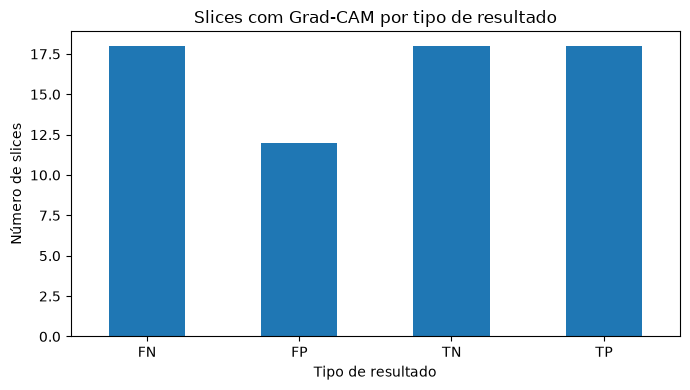

In [4]:
ax = outcome_counts.plot(kind="bar", figsize=(7, 4))

ax.set_title("Slices com Grad-CAM por tipo de resultado")
ax.set_xlabel("Tipo de resultado")
ax.set_ylabel("Número de slices")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 4. Camada usada no Grad-CAM

A implementação detecta automaticamente a última camada convolucional do modelo.

Nesta execução, a camada utilizada foi:


In [5]:
gradcam_cases["target_layer_name"].value_counts()


target_layer_name
features.8    66
Name: count, dtype: int64

## 5. Checagem de consistência das probabilidades

A tabela contém:

- `prob_positive`: probabilidade salva originalmente na predição por slice;
- `gradcam_probability`: probabilidade recalculada ao carregar o checkpoint para gerar o Grad-CAM.

Esses valores devem ser praticamente iguais. Pequenas diferenças poderiam indicar diferença de pré-processamento, mas aqui esperamos consistência.


In [6]:
prob_check = gradcam_cases.copy()
prob_check["abs_diff"] = (
    prob_check["prob_positive"] - prob_check["gradcam_probability"]
).abs()

prob_check[[
    "group_outcome",
    "inferred_group_id",
    "filename",
    "prob_positive",
    "gradcam_probability",
    "abs_diff",
]].sort_values("abs_diff", ascending=False).head(10)


,group_outcome,inferred_group_id,filename,prob_positive,gradcam_probability,abs_diff
37,TN,149-img-00097,149-img-00097-00276.jpg,0.040593,0.040593,3.725290e-09
36,TN,149-img-00097,149-img-00097-00273.jpg,0.026813,0.026813,3.725290e-09
1,FN,207-img-00043,207-img-00043-00246.jpg,0.074334,0.074334,0.000000e+00
0,FN,207-img-00043,207-img-00043-00247.jpg,0.062009,0.062009,0.000000e+00
2,FN,207-img-00043,207-img-00043-00245.jpg,0.086126,0.086126,0.000000e+00
3,FN,207-img-00043,207-img-00043-00249.jpg,0.100682,0.100682,0.000000e+00
6,FN,231-img-00019,231-img-00019-00252.jpg,0.083668,0.083668,0.000000e+00
7,FN,231-img-00019,231-img-00019-00250.jpg,0.094923,0.094923,0.000000e+00
4,FN,207-img-00043,207-img-00043-00250.jpg,0.171641,0.171641,0.000000e+00
5,FN,207-img-00043,207-img-00043-00252.jpg,0.250932,0.250932,0.000000e+00


In [7]:
print("Diferença absoluta máxima:")
print(prob_check["abs_diff"].max())

print("\nDiferença absoluta média:")
print(prob_check["abs_diff"].mean())


Diferença absoluta máxima:
3.725290305400808e-09

Diferença absoluta média:
1.1288758490701095e-10


## 6. Figuras disponíveis

As figuras foram salvas em:

    reports/figures/gradcam/

Cada figura contém:

1. imagem original;
2. mapa Grad-CAM;
3. sobreposição entre imagem e mapa Grad-CAM.


In [8]:
figure_paths = sorted(GRADCAM_FIGURES_DIR.glob("*.png"))

print("Total de figuras encontradas:", len(figure_paths))

for path in figure_paths[:20]:
    print(path.name)

if len(figure_paths) > 20:
    print(f"... mais {len(figure_paths) - 20} figuras")


Total de figuras encontradas: 66
FN_207-img-00043_207-img-00043-00245_gradcam.png
FN_207-img-00043_207-img-00043-00246_gradcam.png
FN_207-img-00043_207-img-00043-00247_gradcam.png
FN_207-img-00043_207-img-00043-00249_gradcam.png
FN_207-img-00043_207-img-00043-00250_gradcam.png
FN_207-img-00043_207-img-00043-00252_gradcam.png
FN_231-img-00019_231-img-00019-00241_gradcam.png
FN_231-img-00019_231-img-00019-00243_gradcam.png
FN_231-img-00019_231-img-00019-00245_gradcam.png
FN_231-img-00019_231-img-00019-00248_gradcam.png
FN_231-img-00019_231-img-00019-00250_gradcam.png
FN_231-img-00019_231-img-00019-00252_gradcam.png
FN_72-img-00032_72-img-00032-00019_gradcam.png
FN_72-img-00032_72-img-00032-00021_gradcam.png
FN_72-img-00032_72-img-00032-00023_gradcam.png
FN_72-img-00032_72-img-00032-00025_gradcam.png
FN_72-img-00032_72-img-00032-00026_gradcam.png
FN_72-img-00032_72-img-00032-00028_gradcam.png
FP_114-img-00064_114-img-00064-00049_gradcam.png
FP_114-img-00064_114-img-00064-00055_gradcam.png

## 7. Função auxiliar para exibir amostras

Para evitar que o notebook fique excessivamente pesado, exibimos uma amostra limitada por tipo de resultado.

As 66 figuras continuam disponíveis localmente em `reports/figures/gradcam/`.


In [9]:
def show_gradcam_examples(outcome: str, max_images: int = 3) -> None:
    """Exibe exemplos Grad-CAM para um tipo de resultado."""
    subset = gradcam_cases[gradcam_cases["group_outcome"] == outcome].copy()

    if subset.empty:
        print(f"Nenhum caso encontrado para {outcome}.")
        return

    subset = subset.sort_values(["inferred_group_id", "prob_positive"]).head(max_images)

    print(f"Exibindo {len(subset)} exemplo(s) de {outcome}")

    for _, row in subset.iterrows():
        figure_path = Path(row["gradcam_figure_path"])

        if not figure_path.exists():
            candidate = GRADCAM_FIGURES_DIR / figure_path.name
            figure_path = candidate

        print("=" * 100)
        print("outcome:", row["group_outcome"])
        print("grupo:", row["inferred_group_id"])
        print("arquivo:", row["filename"])
        print("classe real:", row["label_name"])
        print("classe predita:", row["pred_label_name"])
        print("probabilidade slice:", round(float(row["prob_positive"]), 4))
        print("probabilidade grupo:", round(float(row["group_prob_positive"]), 4))
        print("figura:", figure_path)

        display(Image(filename=str(figure_path)))


## 8. Falsos negativos

Casos reais de `Hepatic_Steatosis` classificados como `Healthy`.

Pergunta principal:

> O modelo deixou de olhar para regiões relevantes ou esses casos têm padrões visuais/técnicos diferentes dos verdadeiros positivos?


Exibindo 3 exemplo(s) de FN
outcome: FN
grupo: 207-img-00043
arquivo: 207-img-00043-00247.jpg
classe real: Hepatic_Steatosis
classe predita: Healthy
probabilidade slice: 0.062
probabilidade grupo: 0.1164
figura: C:\GitHub\mestrado_ml_visao_computacional\reports\figures\gradcam\FN_207-img-00043_207-img-00043-00247_gradcam.png


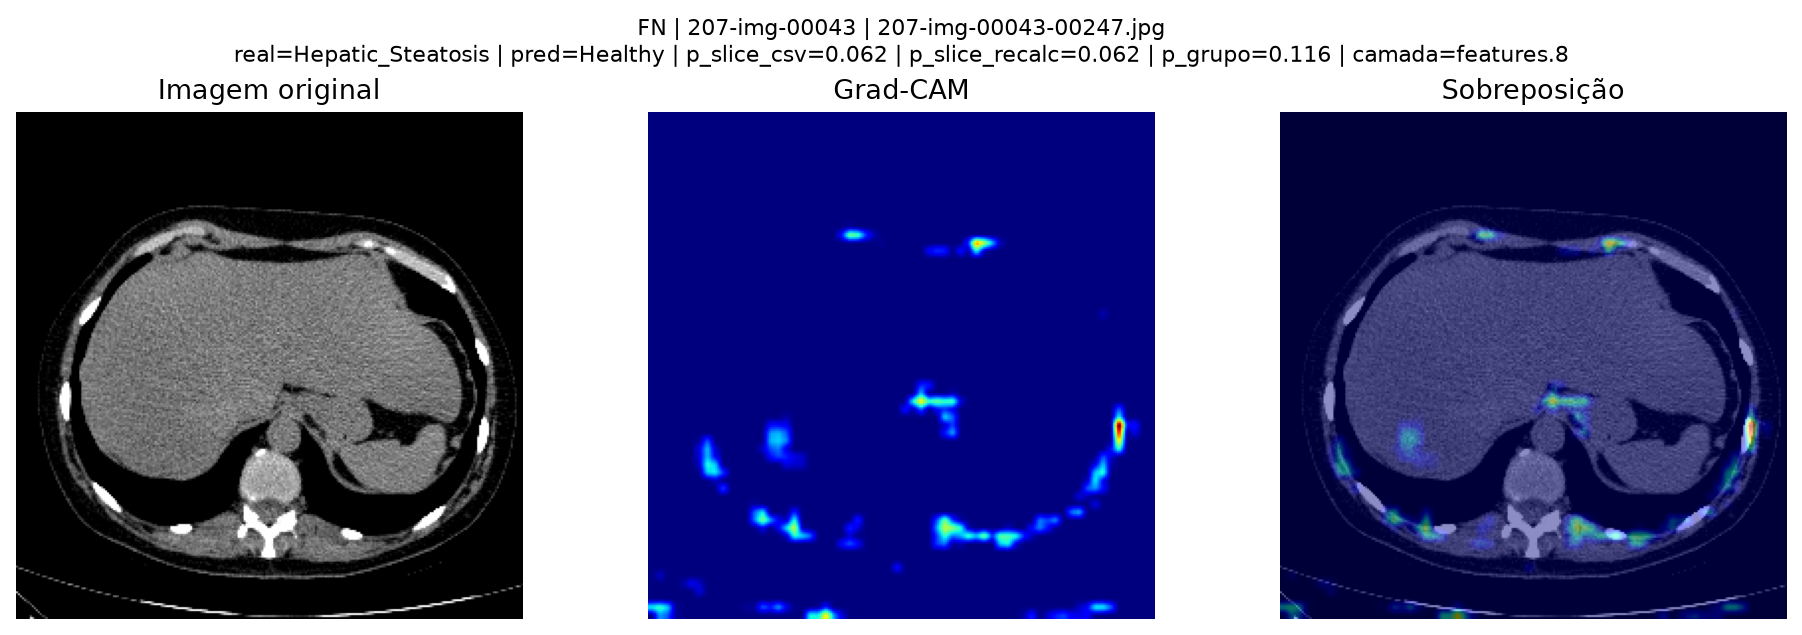

outcome: FN
grupo: 207-img-00043
arquivo: 207-img-00043-00246.jpg
classe real: Hepatic_Steatosis
classe predita: Healthy
probabilidade slice: 0.0743
probabilidade grupo: 0.1164
figura: C:\GitHub\mestrado_ml_visao_computacional\reports\figures\gradcam\FN_207-img-00043_207-img-00043-00246_gradcam.png


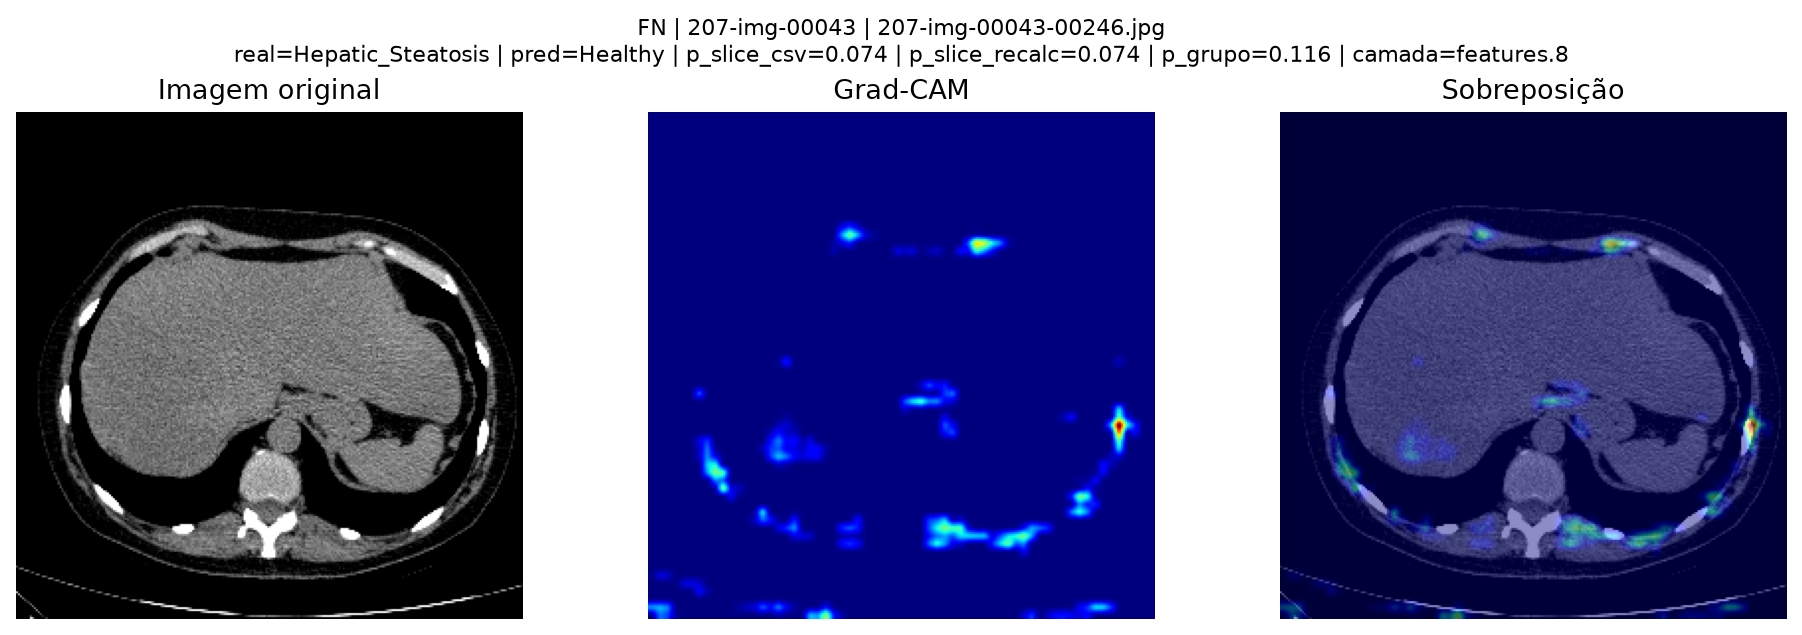

outcome: FN
grupo: 207-img-00043
arquivo: 207-img-00043-00245.jpg
classe real: Hepatic_Steatosis
classe predita: Healthy
probabilidade slice: 0.0861
probabilidade grupo: 0.1164
figura: C:\GitHub\mestrado_ml_visao_computacional\reports\figures\gradcam\FN_207-img-00043_207-img-00043-00245_gradcam.png


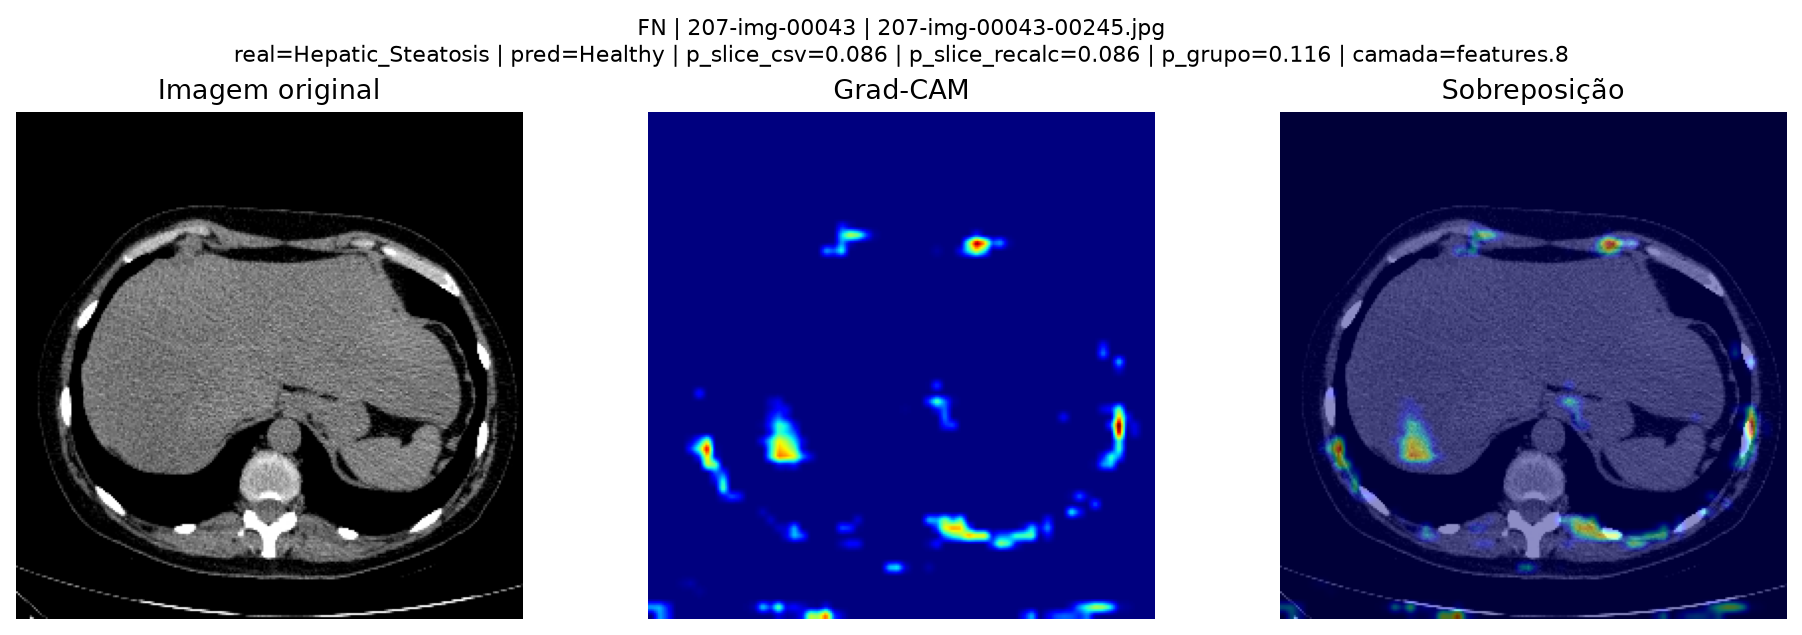

In [10]:
show_gradcam_examples("FN", max_images=3)


## 9. Falsos positivos

Casos reais de `Healthy` classificados como `Hepatic_Steatosis`.

Pergunta principal:

> O modelo está confundindo textura, contraste, ruído, bordas ou artefatos JPEG com sinal de esteatose?


Exibindo 3 exemplo(s) de FP
outcome: FP
grupo: 114-img-00064
arquivo: 114-img-00064-00055.jpg
classe real: Healthy
classe predita: Hepatic_Steatosis
probabilidade slice: 0.7452
probabilidade grupo: 0.8059
figura: C:\GitHub\mestrado_ml_visao_computacional\reports\figures\gradcam\FP_114-img-00064_114-img-00064-00055_gradcam.png


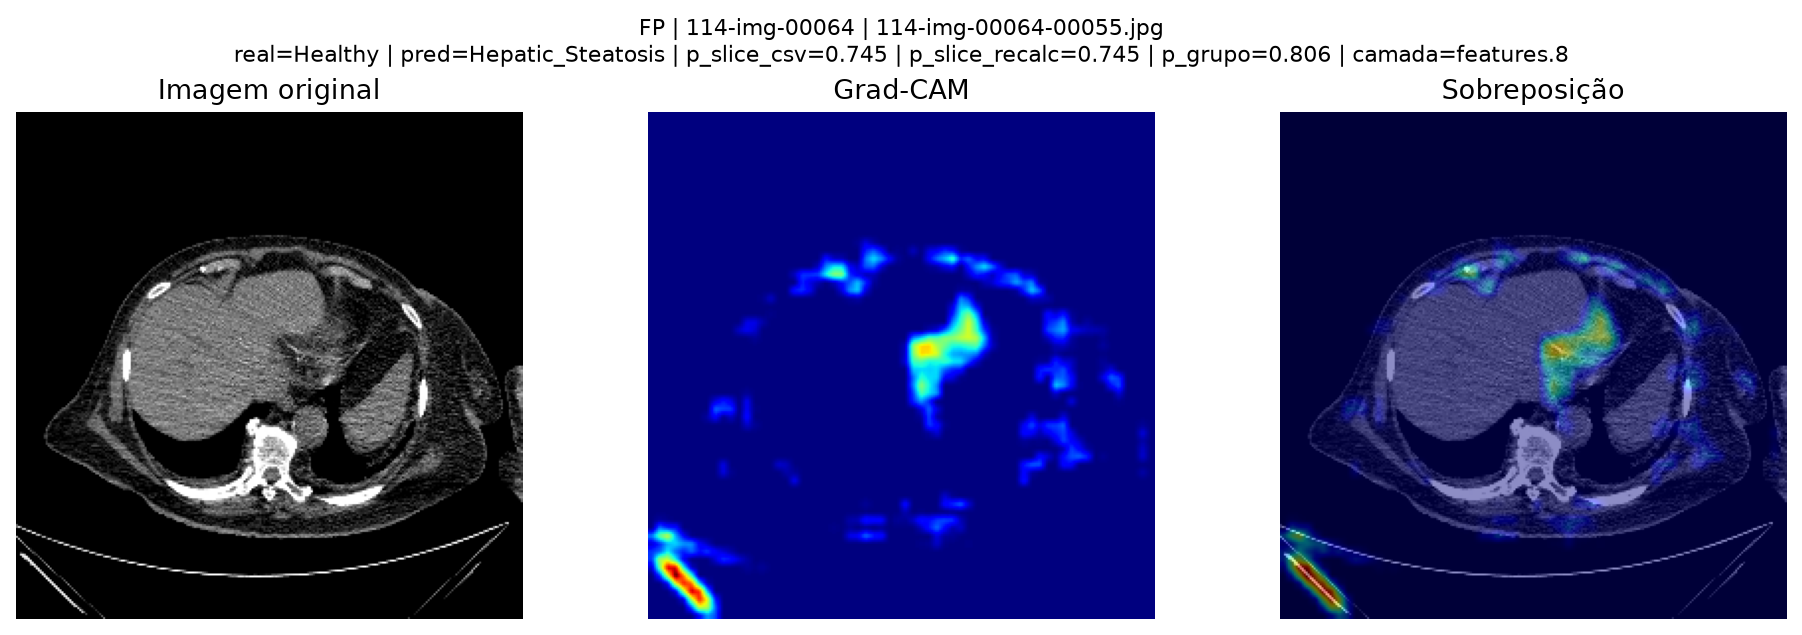

outcome: FP
grupo: 114-img-00064
arquivo: 114-img-00064-00059.jpg
classe real: Healthy
classe predita: Hepatic_Steatosis
probabilidade slice: 0.7796
probabilidade grupo: 0.8059
figura: C:\GitHub\mestrado_ml_visao_computacional\reports\figures\gradcam\FP_114-img-00064_114-img-00064-00059_gradcam.png


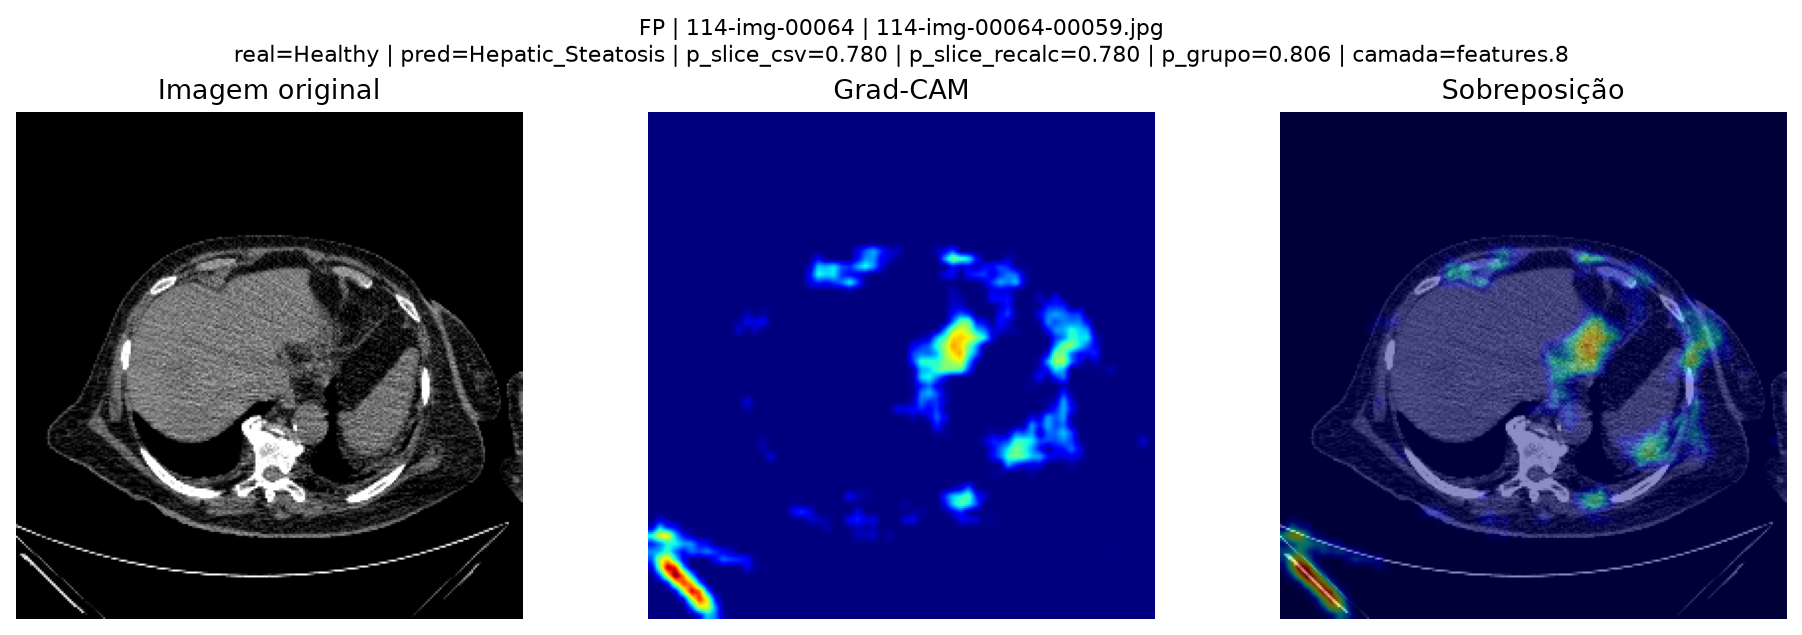

outcome: FP
grupo: 114-img-00064
arquivo: 114-img-00064-00057.jpg
classe real: Healthy
classe predita: Hepatic_Steatosis
probabilidade slice: 0.7907
probabilidade grupo: 0.8059
figura: C:\GitHub\mestrado_ml_visao_computacional\reports\figures\gradcam\FP_114-img-00064_114-img-00064-00057_gradcam.png


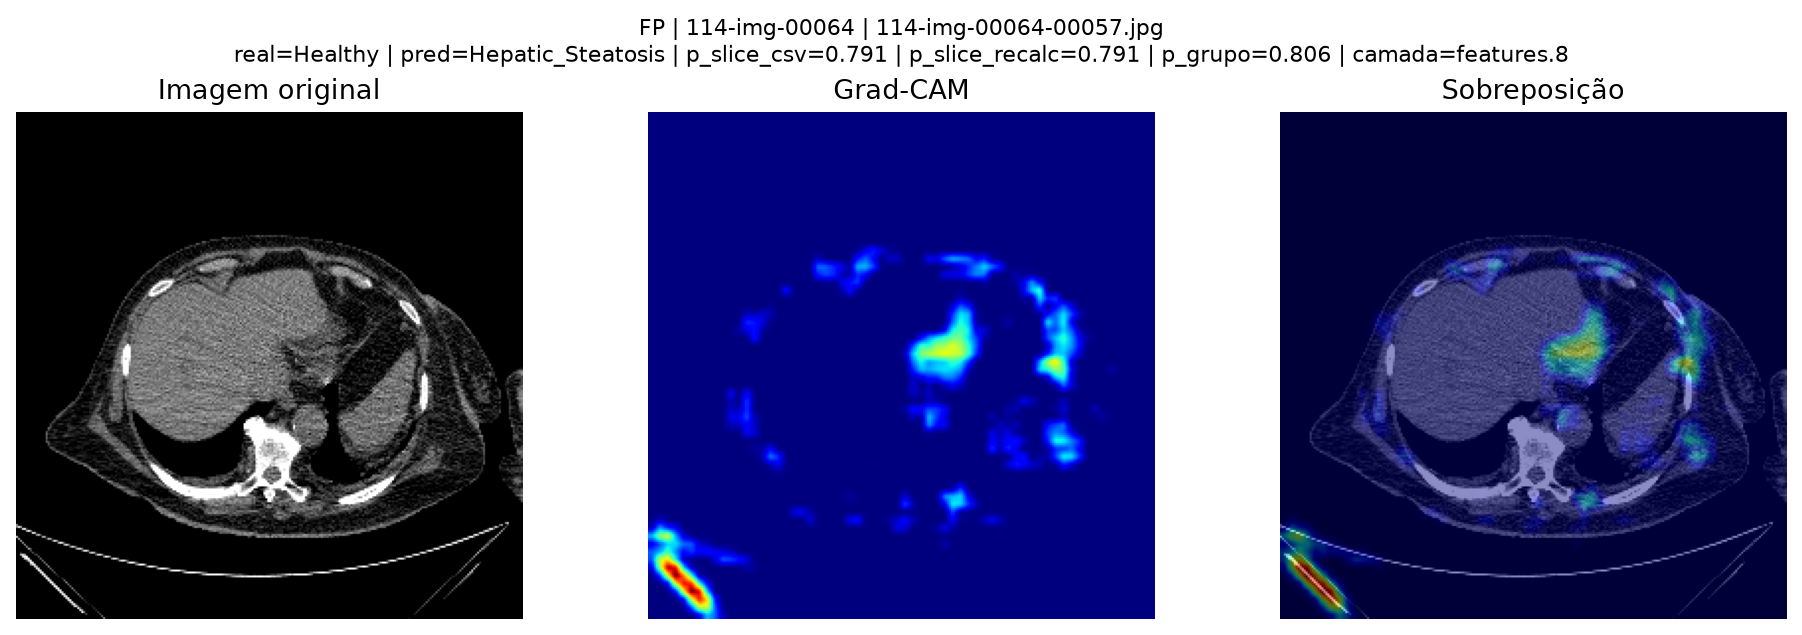

In [11]:
show_gradcam_examples("FP", max_images=3)


## 10. Verdadeiros negativos

Casos reais de `Healthy` classificados corretamente como `Healthy`.

Pergunta principal:

> A baixa probabilidade positiva está associada a ausência de ativação em regiões relevantes ou a um padrão visual global distinto?


Exibindo 3 exemplo(s) de TN


outcome: TN
grupo: 106-img-00060
arquivo: 106-img-00060-00227.jpg
classe real: Healthy
classe predita: Healthy
probabilidade slice: 0.0392
probabilidade grupo: 0.0592
figura: C:\GitHub\mestrado_ml_visao_computacional\reports\figures\gradcam\TN_106-img-00060_106-img-00060-00227_gradcam.png


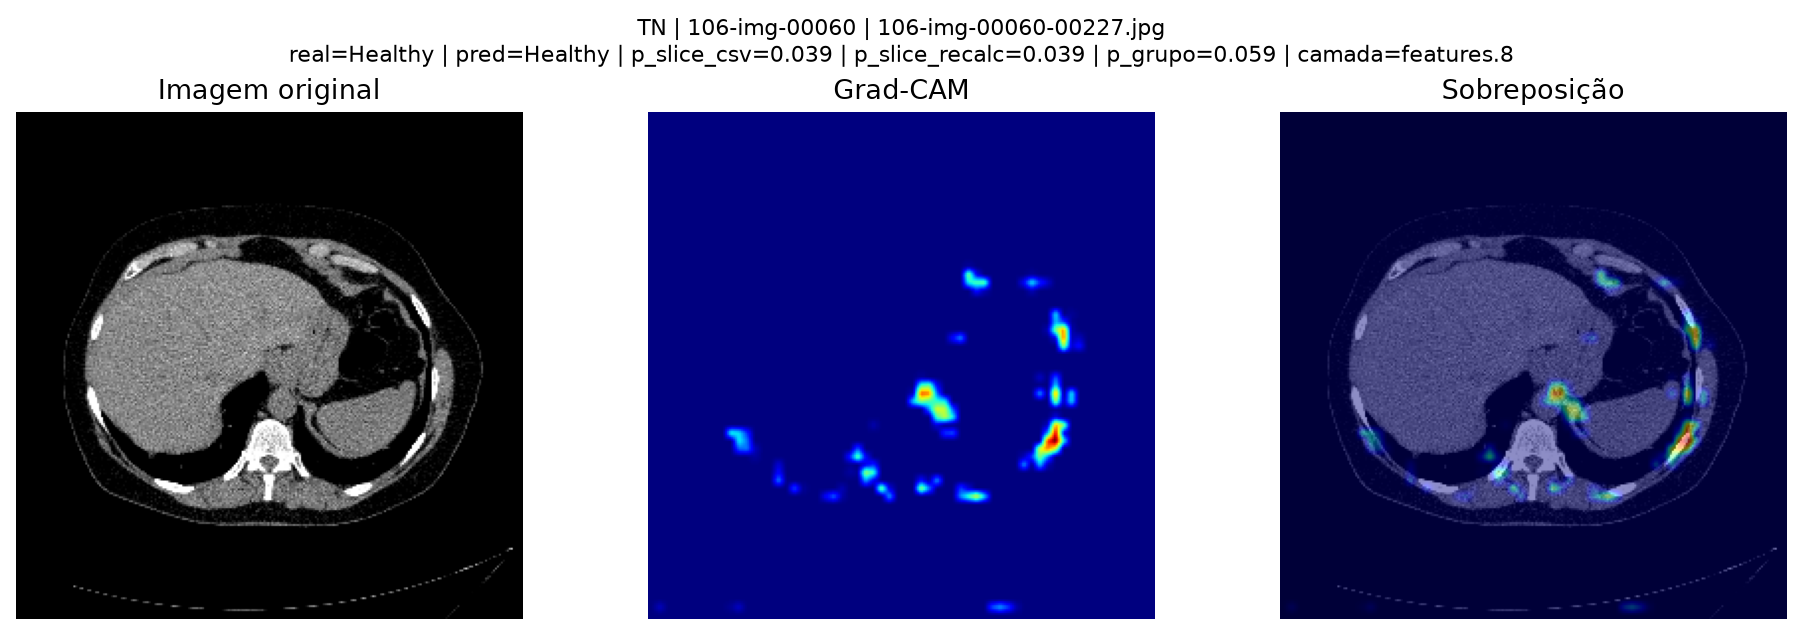

outcome: TN
grupo: 106-img-00060
arquivo: 106-img-00060-00225.jpg
classe real: Healthy
classe predita: Healthy
probabilidade slice: 0.0432
probabilidade grupo: 0.0592
figura: C:\GitHub\mestrado_ml_visao_computacional\reports\figures\gradcam\TN_106-img-00060_106-img-00060-00225_gradcam.png


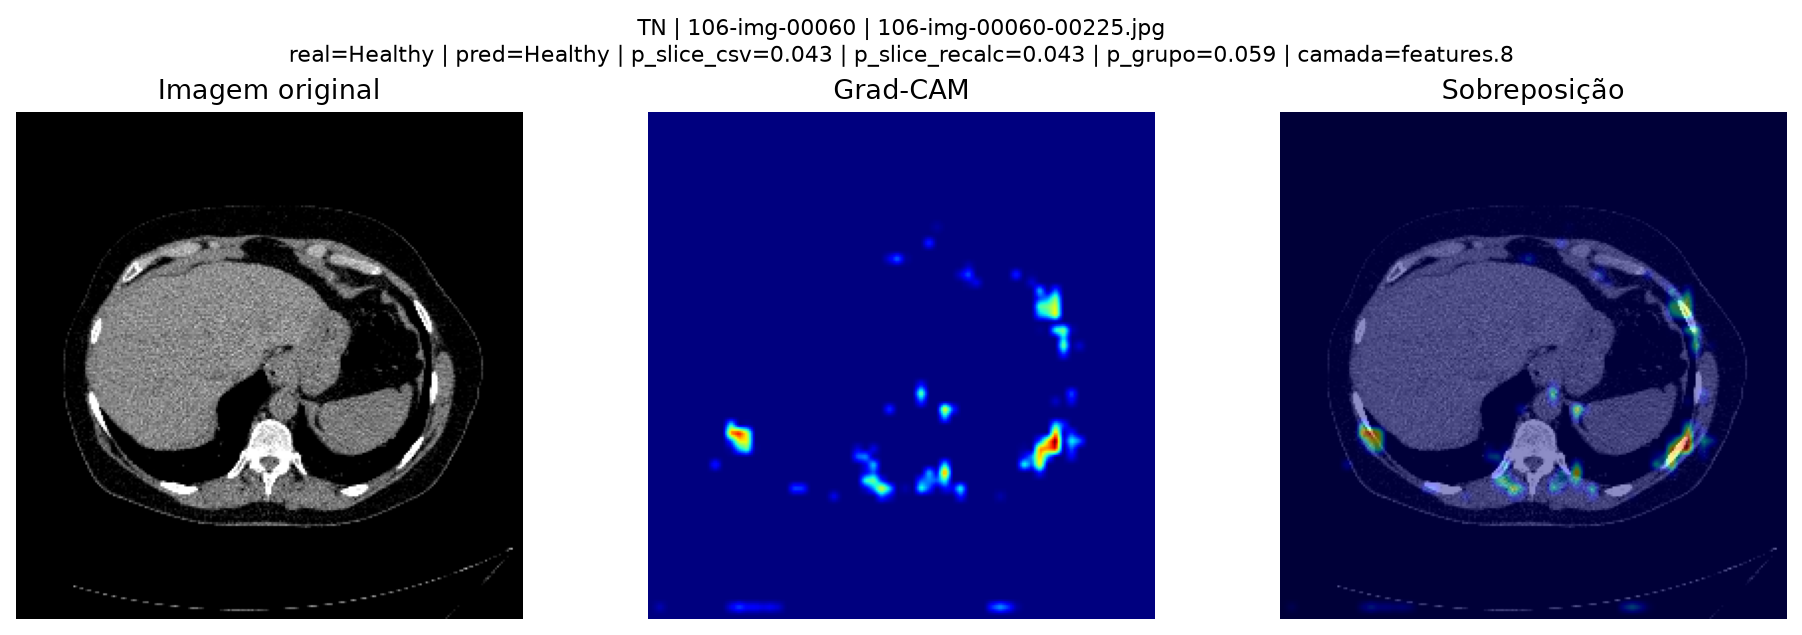

outcome: TN
grupo: 106-img-00060
arquivo: 106-img-00060-00226.jpg
classe real: Healthy
classe predita: Healthy
probabilidade slice: 0.0453
probabilidade grupo: 0.0592
figura: C:\GitHub\mestrado_ml_visao_computacional\reports\figures\gradcam\TN_106-img-00060_106-img-00060-00226_gradcam.png


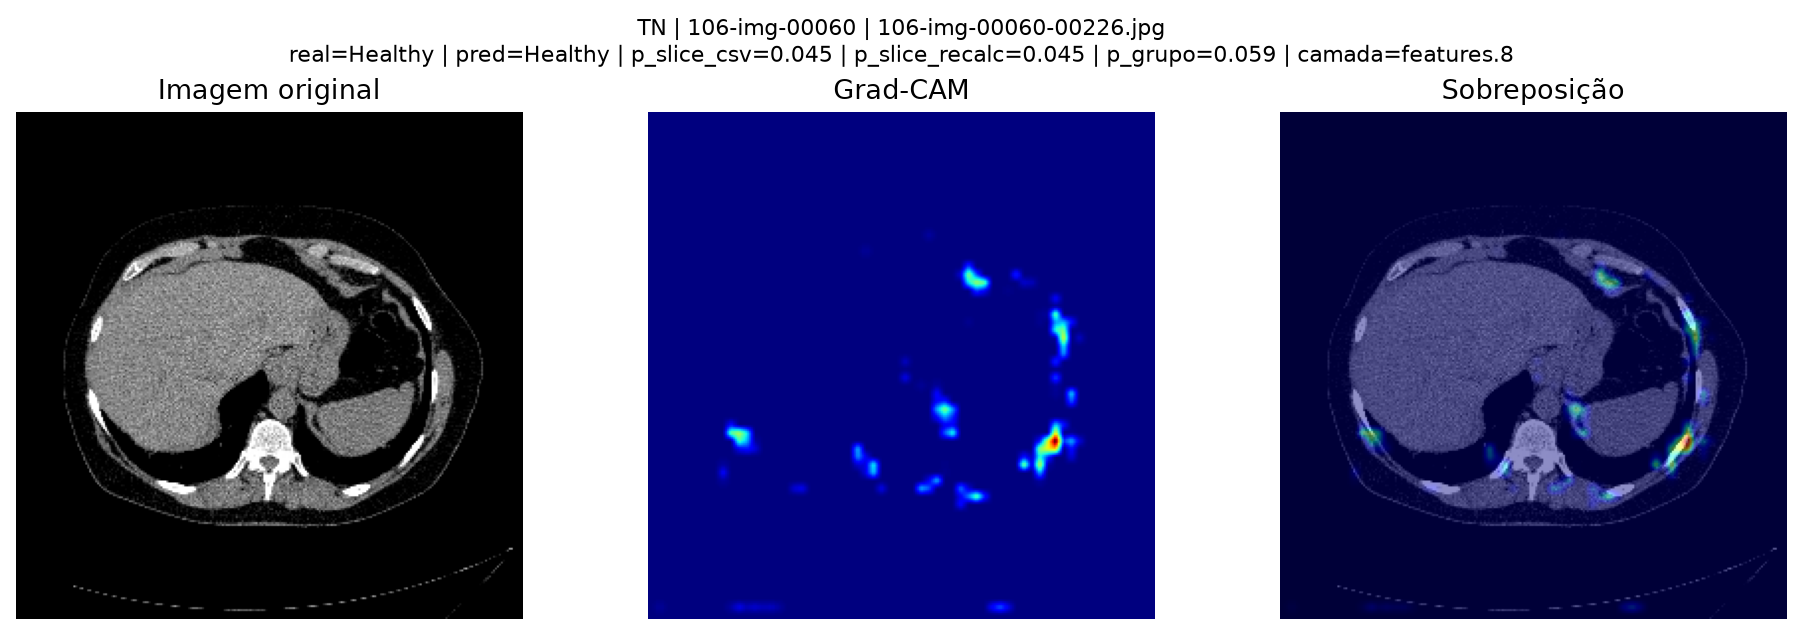

In [12]:
show_gradcam_examples("TN", max_images=3)


## 11. Verdadeiros positivos

Casos reais de `Hepatic_Steatosis` classificados corretamente como `Hepatic_Steatosis`.

Pergunta principal:

> O modelo parece concentrar ativação em regiões plausíveis ou usa padrões globais/artefatos?


Exibindo 3 exemplo(s) de TP
outcome: TP
grupo: 190-img-00028
arquivo: 190-img-00028-00087.jpg
classe real: Hepatic_Steatosis
classe predita: Hepatic_Steatosis
probabilidade slice: 0.993
probabilidade grupo: 0.9956
figura: C:\GitHub\mestrado_ml_visao_computacional\reports\figures\gradcam\TP_190-img-00028_190-img-00028-00087_gradcam.png


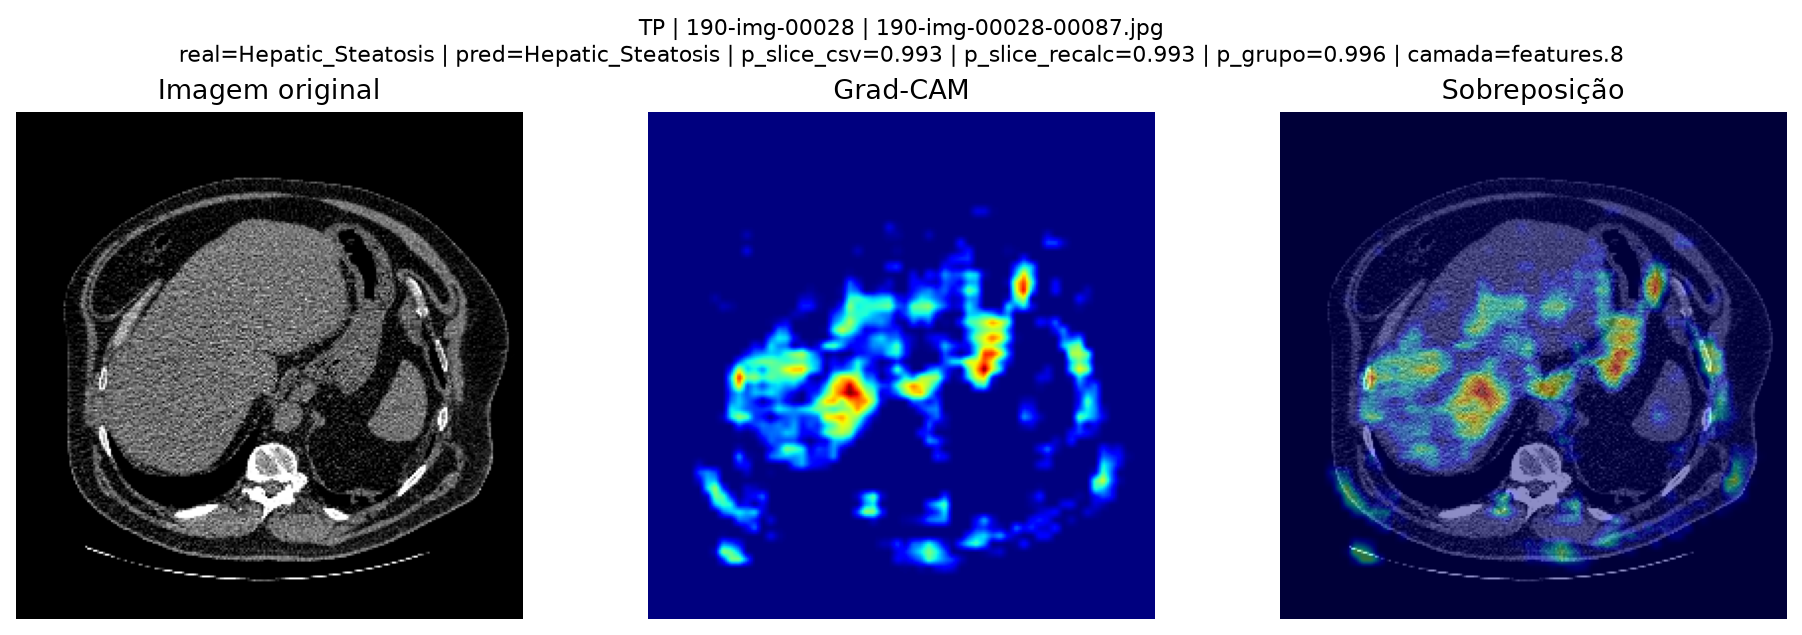


outcome: TP
grupo: 190-img-00028
arquivo: 190-img-00028-00086.jpg
classe real: Hepatic_Steatosis
classe predita: Hepatic_Steatosis
probabilidade slice: 0.9936
probabilidade grupo: 0.9956
figura: C:\GitHub\mestrado_ml_visao_computacional\reports\figures\gradcam\TP_190-img-00028_190-img-00028-00086_gradcam.png


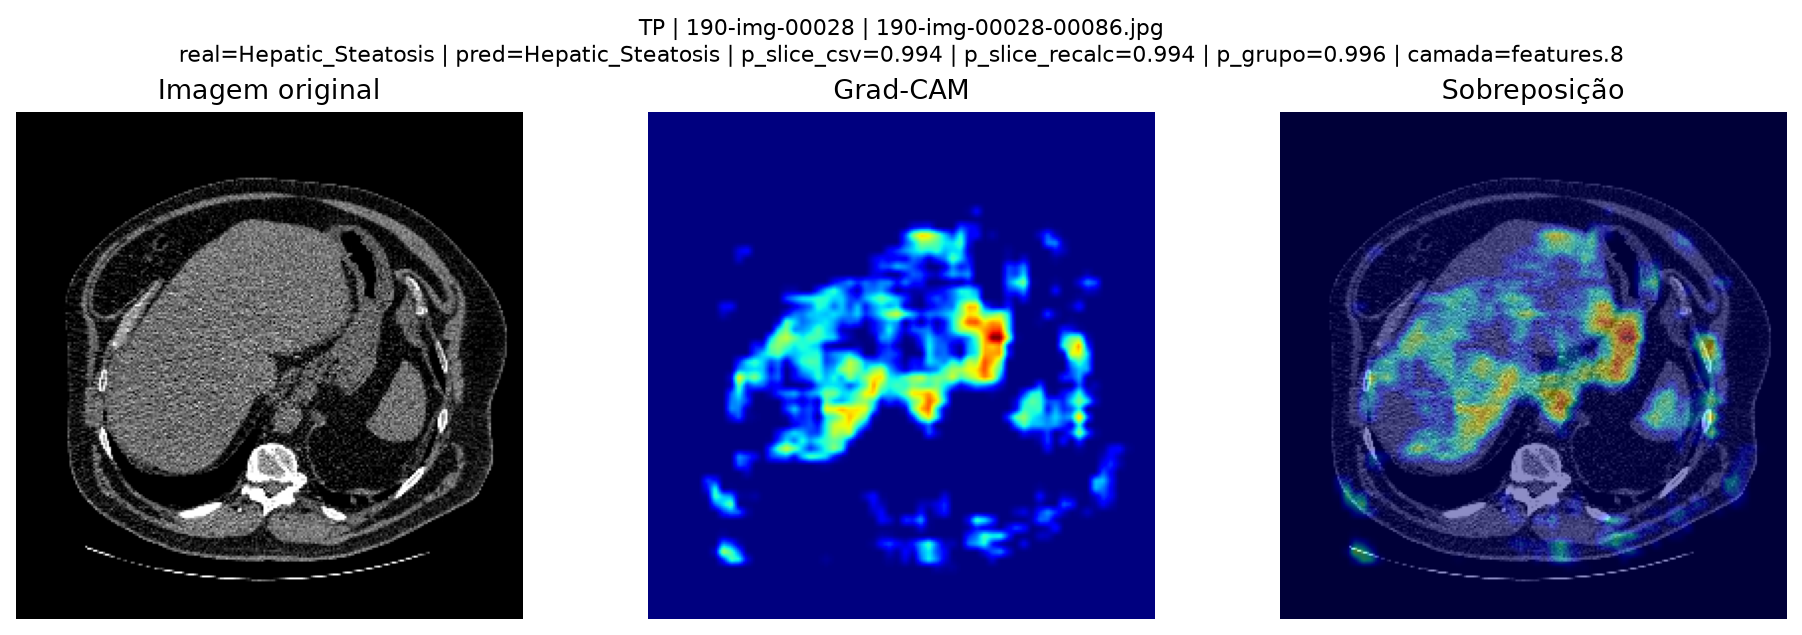

outcome: TP
grupo: 190-img-00028
arquivo: 190-img-00028-00089.jpg
classe real: Hepatic_Steatosis
classe predita: Hepatic_Steatosis
probabilidade slice: 0.9951
probabilidade grupo: 0.9956
figura: C:\GitHub\mestrado_ml_visao_computacional\reports\figures\gradcam\TP_190-img-00028_190-img-00028-00089_gradcam.png


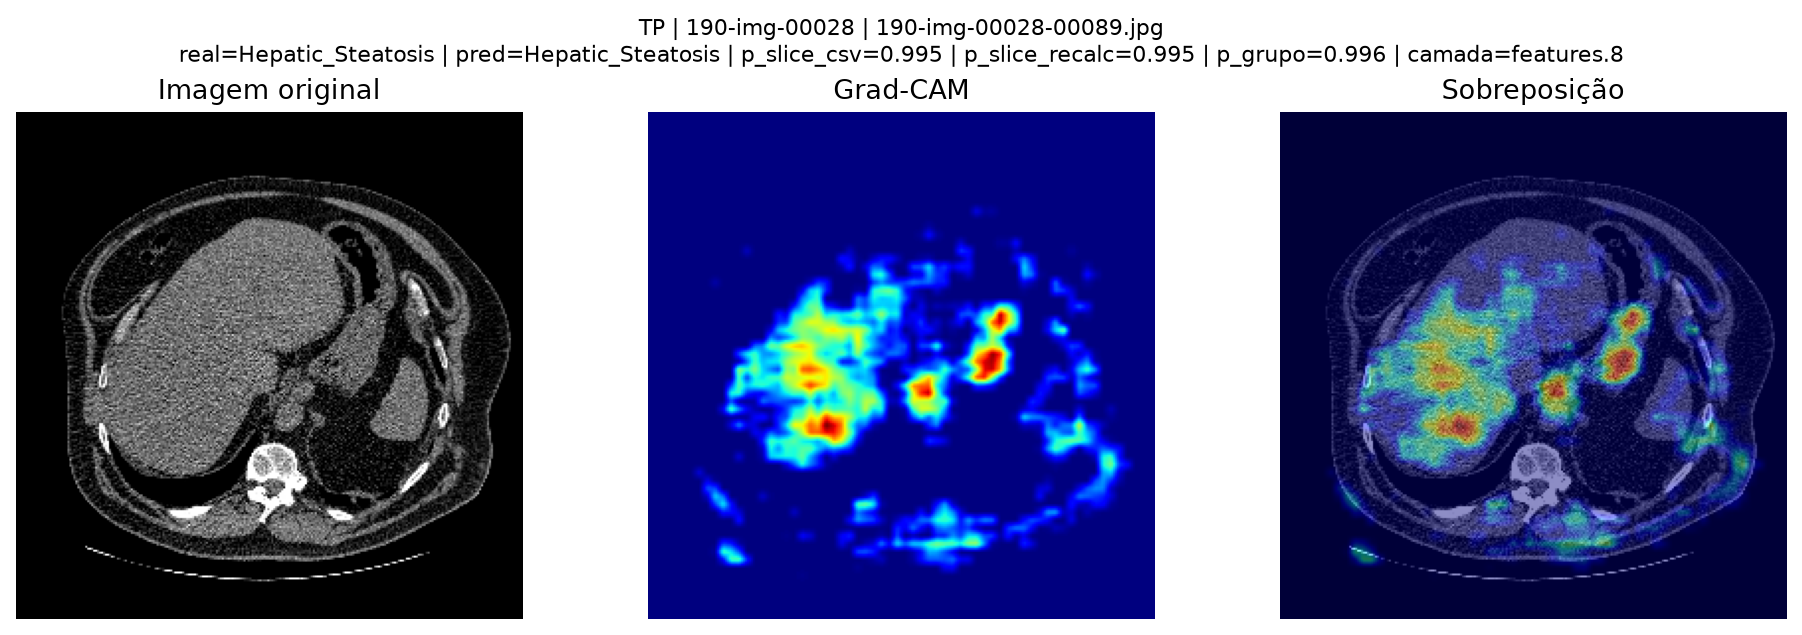

In [13]:
show_gradcam_examples("TP", max_images=3)


## 12. Leitura crítica

O Grad-CAM deve ser interpretado como ferramenta exploratória.

Uma leitura favorável ocorreria se os mapas concentrassem ativação em regiões anatômicas plausíveis, de forma consistente entre verdadeiros positivos e com comportamento coerente nos erros.

Uma leitura preocupante ocorreria se os mapas mostrassem ativação predominante em:

- bordas;
- fundo preto;
- regiões fora do corpo;
- artefatos JPEG;
- ruído;
- estruturas não relacionadas ao fígado;
- padrões globais de contraste.

Como não há segmentação hepática nem metadados clínicos, não é possível afirmar validade clínica apenas com esses mapas.

## 13. Próximos passos possíveis

Próximas melhorias metodológicas:

1. revisar visualmente os mapas com apoio de especialista;
2. criar segmentação ou máscara aproximada da região hepática;
3. testar modelos com controle para atalhos visuais;
4. validar em base externa;
5. comparar CNN com baseline estatístico e modelos mais robustos;
6. avaliar se o modelo depende de textura global, compressão ou contraste.
